# HW14 — Эмбеддинги, FAISS, оценка retrieval и mini-RAG

**Тема:** построение векторных представлений, индекс FAISS, оценка качества retrieval, обновление базы знаний, mini-RAG.

**База знаний:** справочник по Python — основные концепции, стандартная библиотека, паттерны.

## 1. Импорты, seed и среда

In [1]:
import random
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f'Seed: {SEED}')
print(f'Устройство: CPU')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'FAISS: {faiss.__version__}')

Seed: 42
Устройство: CPU
NumPy: 2.0.2
Pandas: 2.3.3
FAISS: 1.13.0


## 2. База знаний и первичный анализ

Используется собственная текстовая база знаний — справочник по Python. Содержит 20 документов по ключевым темам: типы данных, функции, ООП, модули стандартной библиотеки, обработка ошибок и т.д.

Эта база подходит для retrieval/mini-RAG, потому что:
- документы тематически связаны, но покрывают разные аспекты;
- по ним можно формулировать конкретные вопросы с однозначными ответами;
- масштаб позволяет увидеть работу retrieval без избыточной сложности.

In [2]:
documents = [
    {
        "id": "doc_01",
        "title": "Списки в Python",
        "text": "Список (list) — это упорядоченная изменяемая коллекция элементов в Python. Списки создаются с помощью квадратных скобок: my_list = [1, 2, 3]. Списки поддерживают индексацию, срезы, добавление элементов через append() и extend(), удаление через remove() и pop(). Списки могут содержать элементы разных типов. Для сортировки используется метод sort() (на месте) или функция sorted() (возвращает новый список). Списочные выражения (list comprehension) позволяют создавать списки в одну строку: [x**2 for x in range(10)]. Сложность доступа по индексу — O(1), добавления в конец — амортизированная O(1), вставки в начало — O(n)."
    },
    {
        "id": "doc_02",
        "title": "Словари в Python",
        "text": "Словарь (dict) — это неупорядоченная коллекция пар ключ-значение. Создаётся с помощью фигурных скобок: d = {'name': 'Alice', 'age': 30}. Ключи должны быть хэшируемыми (строки, числа, кортежи). Доступ к значению по ключу — O(1) в среднем. Методы: get() для безопасного доступа, keys(), values(), items() для итерации. Метод update() объединяет словари. С Python 3.7 словари сохраняют порядок вставки. defaultdict из модуля collections позволяет задать значение по умолчанию для отсутствующих ключей. Словарные выражения: {k: v for k, v in pairs}."
    },
    {
        "id": "doc_03",
        "title": "Множества в Python",
        "text": "Множество (set) — это неупорядоченная коллекция уникальных элементов. Создаётся через set() или фигурные скобки: s = {1, 2, 3}. Множества поддерживают операции объединения (union, |), пересечения (intersection, &), разности (difference, -) и симметрической разности (symmetric_difference, ^). Проверка принадлежности элемента — O(1). Множества удобны для удаления дубликатов из списка: unique = list(set(my_list)). frozenset — неизменяемый аналог множества, который можно использовать как ключ словаря."
    },
    {
        "id": "doc_04",
        "title": "Кортежи в Python",
        "text": "Кортеж (tuple) — это упорядоченная неизменяемая коллекция элементов. Создаётся с помощью круглых скобок: t = (1, 2, 3). Кортежи поддерживают индексацию и срезы, но не позволяют изменять элементы после создания. Кортежи хэшируемы (если все элементы хэшируемы) и могут использоваться как ключи словаря. Named tuples из модуля collections позволяют создавать кортежи с именованными полями. Распаковка кортежей: a, b, c = (1, 2, 3). Кортежи занимают меньше памяти, чем списки, и быстрее создаются."
    },
    {
        "id": "doc_05",
        "title": "Строки в Python",
        "text": "Строки (str) в Python — это неизменяемые последовательности символов Unicode. Строки поддерживают конкатенацию (+), повторение (*), индексацию и срезы. Основные методы: split() для разделения, join() для объединения, strip() для удаления пробелов, replace() для замены подстрок, find() и index() для поиска. f-строки (f'Hello {name}') — удобный способ форматирования с Python 3.6. Метод format() — альтернативный способ форматирования. Строки можно сравнивать лексикографически. Метод encode() преобразует строку в байты."
    },
    {
        "id": "doc_06",
        "title": "Функции в Python",
        "text": "Функции в Python определяются с помощью ключевого слова def. Функции могут принимать позиционные и именованные аргументы, аргументы по умолчанию, *args и **kwargs. Функции — это объекты первого класса: их можно присваивать переменным, передавать как аргументы и возвращать из других функций. Лямбда-функции (lambda) создают анонимные функции в одну строку. Декораторы (@decorator) позволяют модифицировать поведение функций. Генераторы — функции с yield, которые возвращают итератор и экономят память. Рекурсия поддерживается, но лимит стека по умолчанию — 1000 вызовов."
    },
    {
        "id": "doc_07",
        "title": "Классы и ООП в Python",
        "text": "Классы в Python определяются с помощью ключевого слова class. Конструктор — метод __init__(self). Python поддерживает одиночное и множественное наследование. Инкапсуляция реализуется через соглашения об именовании: _private, __mangled. Полиморфизм достигается через переопределение методов. Специальные методы (dunder methods): __str__, __repr__, __len__, __eq__, __lt__ и другие позволяют настраивать поведение объектов. Декоратор @property создаёт свойства с геттером и сеттером. @classmethod и @staticmethod — методы класса и статические методы. Абстрактные классы реализуются через модуль abc."
    },
    {
        "id": "doc_08",
        "title": "Обработка исключений в Python",
        "text": "Обработка исключений в Python выполняется с помощью конструкции try-except-else-finally. Блок try содержит код, который может вызвать исключение. Блок except ловит конкретные типы исключений. Блок else выполняется, если исключений не было. Блок finally выполняется всегда. Можно создавать собственные исключения, наследуясь от Exception. Оператор raise выбрасывает исключение. Контекстные менеджеры (with) обеспечивают корректное освобождение ресурсов. Основные встроенные исключения: ValueError, TypeError, KeyError, IndexError, FileNotFoundError, ZeroDivisionError."
    },
    {
        "id": "doc_09",
        "title": "Работа с файлами в Python",
        "text": "Работа с файлами в Python осуществляется через функцию open(). Рекомендуется использовать контекстный менеджер with для автоматического закрытия файлов. Режимы открытия: 'r' — чтение, 'w' — запись (перезапись), 'a' — дополнение, 'b' — бинарный режим. Методы чтения: read(), readline(), readlines(). Для записи: write(), writelines(). Модуль pathlib предоставляет объектно-ориентированный интерфейс для работы с путями. Модуль os содержит функции для работы с файловой системой. Модуль json позволяет читать и записывать JSON-файлы. Модуль csv — для работы с CSV-файлами."
    },
    {
        "id": "doc_10",
        "title": "Модуль itertools",
        "text": "Модуль itertools предоставляет функции для создания эффективных итераторов. count() — бесконечный счётчик. cycle() — бесконечный цикл по итерируемому объекту. repeat() — повторение элемента. chain() — объединение нескольких итерируемых объектов. product() — декартово произведение. permutations() и combinations() — перестановки и комбинации. groupby() — группировка последовательных элементов. islice() — срез итератора. accumulate() — накопительные суммы. starmap() — применение функции к распакованным аргументам."
    },
    {
        "id": "doc_11",
        "title": "Модуль collections",
        "text": "Модуль collections содержит специализированные контейнерные типы данных. Counter — подсчёт элементов: Counter(['a', 'b', 'a']) возвращает Counter({'a': 2, 'b': 1}). deque — двусторонняя очередь с O(1) операциями добавления и удаления с обоих концов. OrderedDict — словарь, запоминающий порядок вставки (актуально до Python 3.7). defaultdict — словарь со значением по умолчанию. namedtuple — фабрика для создания кортежей с именованными полями. ChainMap — объединение нескольких словарей в один вид."
    },
    {
        "id": "doc_12",
        "title": "Декораторы в Python",
        "text": "Декораторы — это функции, которые принимают другую функцию и возвращают модифицированную версию. Синтаксис @decorator перед определением функции. Декораторы используются для логирования, проверки прав доступа, кэширования, измерения времени выполнения. functools.wraps сохраняет метаданные оборачиваемой функции. Декораторы с аргументами реализуются через дополнительную вложенную функцию. Декораторы классов принимают класс и возвращают модифицированный класс. Встроенные декораторы: @property, @classmethod, @staticmethod. functools.lru_cache — встроенный декоратор для кэширования результатов функции."
    },
    {
        "id": "doc_13",
        "title": "Генераторы и итераторы в Python",
        "text": "Итератор — объект, реализующий методы __iter__() и __next__(). Генератор — функция с ключевым словом yield, которая автоматически создаёт итератор. Генераторные выражения аналогичны списочным, но используют круглые скобки: (x**2 for x in range(10)). Генераторы экономят память, вычисляя значения лениво (lazy evaluation). Метод send() позволяет отправлять значения в генератор. Метод throw() выбрасывает исключение внутри генератора. yield from делегирует выполнение подгенератору. Протокол итератора используется в циклах for, функциях map(), filter(), zip()."
    },
    {
        "id": "doc_14",
        "title": "Модуль re — регулярные выражения",
        "text": "Модуль re предоставляет функции для работы с регулярными выражениями. re.search() ищет первое совпадение в строке. re.match() проверяет совпадение в начале строки. re.findall() возвращает все совпадения. re.sub() заменяет совпадения. re.split() разбивает строку по паттерну. re.compile() создаёт скомпилированный объект регулярного выражения для повторного использования. Основные паттерны: \\d (цифра), \\w (буква/цифра), \\s (пробел), . (любой символ), * (0+), + (1+), ? (0 или 1). Группы захвата: (pattern), именованные группы: (?P<name>pattern)."
    },
    {
        "id": "doc_15",
        "title": "Виртуальные окружения и pip",
        "text": "Виртуальные окружения изолируют зависимости проектов друг от друга. Создание: python -m venv myenv. Активация: source myenv/bin/activate (Linux/Mac) или myenv\\Scripts\\activate (Windows). pip — менеджер пакетов Python. pip install package — установка пакета. pip freeze > requirements.txt — фиксация зависимостей. pip install -r requirements.txt — установка из файла. Альтернативы: conda, poetry, pipenv. pyproject.toml — современный стандарт описания проекта (PEP 517/518). pip поддерживает установку из git-репозиториев и локальных файлов."
    },
    {
        "id": "doc_16",
        "title": "Асинхронное программирование в Python",
        "text": "Асинхронное программирование в Python реализуется через модуль asyncio. Корутины определяются с async def и вызываются с await. asyncio.run() запускает главную корутину. asyncio.gather() выполняет несколько корутин параллельно. asyncio.create_task() создаёт задачу для конкурентного выполнения. Асинхронные генераторы используют async for. Асинхронные контекстные менеджеры — async with. aiohttp — популярная библиотека для асинхронных HTTP-запросов. Асинхронность эффективна для I/O-bound задач, но не для CPU-bound. GIL не влияет на асинхронный код, так как он работает в одном потоке."
    },
    {
        "id": "doc_17",
        "title": "Тестирование в Python",
        "text": "Модуль unittest — стандартный фреймворк для тестирования. Тесты организуются в классы, наследующиеся от unittest.TestCase. Основные assert-методы: assertEqual, assertTrue, assertRaises. pytest — популярный сторонний фреймворк: более простой синтаксис, мощные фикстуры, параметризация. Фикстуры pytest: @pytest.fixture для подготовки данных. Параметризация: @pytest.mark.parametrize для запуска теста с разными данными. mock и unittest.mock — для создания подставных объектов. coverage — инструмент для измерения покрытия кода тестами. Типы тестов: unit, integration, end-to-end."
    },
    {
        "id": "doc_18",
        "title": "Работа с датой и временем в Python",
        "text": "Модуль datetime содержит классы для работы с датой и временем. datetime.datetime — дата и время. datetime.date — только дата. datetime.time — только время. datetime.timedelta — разница между датами. strftime() форматирует дату в строку. strptime() парсит строку в дату. Модуль time предоставляет функции для работы с временными метками Unix. time.sleep() — пауза выполнения. Модуль calendar — работа с календарём. Библиотека pytz (или zoneinfo в Python 3.9+) — работа с часовыми поясами. arrow и pendulum — популярные сторонние библиотеки для удобной работы с датами."
    },
    {
        "id": "doc_19",
        "title": "Модуль logging",
        "text": "Модуль logging — стандартный инструмент для ведения журналов в Python. Уровни логирования: DEBUG, INFO, WARNING, ERROR, CRITICAL. Базовая настройка: logging.basicConfig(level=logging.INFO). Логгер создаётся через logging.getLogger(__name__). Handler определяет, куда отправлять логи: StreamHandler (консоль), FileHandler (файл), RotatingFileHandler (файл с ротацией). Formatter задаёт формат сообщений. Конфигурация через словарь: logging.config.dictConfig(). Логирование исключений: logger.exception() автоматически добавляет traceback. Не рекомендуется использовать print() для логирования в production-коде."
    },
    {
        "id": "doc_20",
        "title": "Типизация в Python",
        "text": "Модуль typing предоставляет инструменты для аннотации типов. Базовые аннотации: def func(x: int) -> str. Обобщённые типы: List[int], Dict[str, int], Tuple[int, ...], Optional[str]. Union[int, str] — один из нескольких типов. С Python 3.10 можно писать int | str вместо Union. TypeVar — для создания обобщённых функций. Protocol — для структурной типизации (duck typing). dataclasses — декоратор @dataclass автоматически генерирует __init__, __repr__, __eq__. mypy — статический анализатор типов. Типизация не влияет на выполнение, но помогает находить ошибки и улучшает читаемость кода."
    }
]

print(f'Число документов: {len(documents)}')
print()
for doc in documents[:5]:
    print(f"[{doc['id']}] {doc['title']}")
    print(f"  {doc['text'][:120]}...")
    print()

Число документов: 20

[doc_01] Списки в Python
  Список (list) — это упорядоченная изменяемая коллекция элементов в Python. Списки создаются с помощью квадратных скобок:...

[doc_02] Словари в Python
  Словарь (dict) — это неупорядоченная коллекция пар ключ-значение. Создаётся с помощью фигурных скобок: d = {'name': 'Ali...

[doc_03] Множества в Python
  Множество (set) — это неупорядоченная коллекция уникальных элементов. Создаётся через set() или фигурные скобки: s = {1,...

[doc_04] Кортежи в Python
  Кортеж (tuple) — это упорядоченная неизменяемая коллекция элементов. Создаётся с помощью круглых скобок: t = (1, 2, 3). ...

[doc_05] Строки в Python
  Строки (str) в Python — это неизменяемые последовательности символов Unicode. Строки поддерживают конкатенацию (+), повт...



## 3. Чанкинг документов

Используем фиксированное разбиение по символам с перекрытием (overlap). Параметры:
- `chunk_size = 200` символов
- `overlap = 50` символов

In [3]:
def chunk_text(text, chunk_size=200, overlap=50):
    """Разбивает текст на чанки с перекрытием."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        if chunk.strip():
            chunks.append(chunk.strip())
        start += chunk_size - overlap
    return chunks


def build_chunks(documents, chunk_size=200, overlap=50):
    """Создаёт чанки из всех документов с метаданными."""
    all_chunks = []
    for doc in documents:
        text_chunks = chunk_text(doc['text'], chunk_size, overlap)
        for i, chunk in enumerate(text_chunks):
            all_chunks.append({
                'doc_id': doc['id'],
                'title': doc['title'],
                'chunk_idx': i,
                'text': chunk
            })
    return all_chunks


CHUNK_SIZE = 200
OVERLAP = 50

chunks = build_chunks(documents, CHUNK_SIZE, OVERLAP)
print(f'Число чанков: {len(chunks)}')
print()

# Пример: как один документ превращается в чанки
example_doc = documents[0]
example_chunks = chunk_text(example_doc['text'], CHUNK_SIZE, OVERLAP)
print(f"Документ: '{example_doc['title']}' ({len(example_doc['text'])} символов) -> {len(example_chunks)} чанков")
for i, ch in enumerate(example_chunks):
    print(f"  Чанк {i}: [{len(ch)} симв.] {ch[:80]}...")

Число чанков: 83

Документ: 'Списки в Python' (623 символов) -> 5 чанков
  Чанк 0: [200 симв.] Список (list) — это упорядоченная изменяемая коллекция элементов в Python. Списк...
  Чанк 1: [200 симв.] оддерживают индексацию, срезы, добавление элементов через append() и extend(), у...
  Чанк 2: [199 симв.] типов. Для сортировки используется метод sort() (на месте) или функция sorted() ...
  Чанк 3: [173 симв.] озволяют создавать списки в одну строку: [x**2 for x in range(10)]. Сложность до...
  Чанк 4: [23 симв.] ставки в начало — O(n)....


## 4. Эмбеддинги и индекс FAISS

Используем TF-IDF + SVD для построения плотных векторных представлений чанков. Это позволяет работать полностью офлайн и быстро.

- TF-IDF — взвешенная частотная векторизация
- TruncatedSVD — снижение размерности (аналог LSA — Latent Semantic Analysis)

In [4]:
EMBED_DIM = 64

class TfidfEmbedder:
    """Эмбеддер на основе TF-IDF + SVD."""
    
    def __init__(self, dim=EMBED_DIM):
        self.vectorizer = TfidfVectorizer(
            max_features=5000,
            sublinear_tf=True,
            ngram_range=(1, 2)
        )
        self.target_dim = dim
        self.dim = dim
        self._fitted = False
    
    def _make_svd(self, n_samples, n_features):
        actual_dim = min(self.target_dim, n_samples - 1, n_features)
        self.svd = TruncatedSVD(n_components=actual_dim, random_state=SEED)
        self.dim = actual_dim
    
    def fit(self, texts):
        tfidf = self.vectorizer.fit_transform(texts)
        self._make_svd(tfidf.shape[0], tfidf.shape[1])
        self.svd.fit(tfidf)
        self._fitted = True
        return self
    
    def encode(self, texts):
        tfidf = self.vectorizer.transform(texts)
        embeddings = self.svd.transform(tfidf).astype('float32')
        return embeddings
    
    def fit_encode(self, texts):
        tfidf = self.vectorizer.fit_transform(texts)
        self._make_svd(tfidf.shape[0], tfidf.shape[1])
        embeddings = self.svd.fit_transform(tfidf).astype('float32')
        self._fitted = True
        return embeddings


chunk_texts = [c['text'] for c in chunks]
embedder = TfidfEmbedder(dim=EMBED_DIM)
embeddings = embedder.fit_encode(chunk_texts)

print(f'Размерность эмбеддингов: {embeddings.shape}')
print(f'Объяснённая дисперсия SVD: {embedder.svd.explained_variance_ratio_.sum():.3f}')

Размерность эмбеддингов: (83, 64)
Объяснённая дисперсия SVD: 0.856


In [5]:
# Нормализуем для косинусного сходства
faiss.normalize_L2(embeddings)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # Inner Product после нормализации = cosine similarity
index.add(embeddings)

print(f'Индекс FAISS: {index.ntotal} векторов, размерность {dimension}')
print(f'Тип индекса: IndexFlatIP (cosine similarity через inner product)')

Индекс FAISS: 83 векторов, размерность 64
Тип индекса: IndexFlatIP (cosine similarity через inner product)


In [6]:
TOP_K = 5

def search(query, index, embedder, chunks, top_k=TOP_K):
    """Поиск top-k релевантных чанков по запросу."""
    query_emb = embedder.encode([query])
    faiss.normalize_L2(query_emb)
    scores, indices = index.search(query_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            results.append({
                'score': float(score),
                'chunk': chunks[idx],
                'chunk_idx': idx
            })
    return results


# Примеры поиска
test_queries = [
    "Как создать словарь в Python?",
    "Что такое декоратор?",
    "Как работать с файлами?",
    "Чем отличается список от кортежа?",
    "Как писать тесты в Python?"
]

for q in test_queries:
    results = search(q, index, embedder, chunks, top_k=3)
    print(f'Запрос: "{q}"')
    for r in results:
        print(f'  [{r["score"]:.3f}] ({r["chunk"]["doc_id"]}) {r["chunk"]["title"]} — чанк {r["chunk"]["chunk_idx"]}')
    print()

Запрос: "Как создать словарь в Python?"
  [0.696] (doc_11) Модуль collections — чанк 1
  [0.471] (doc_03) Множества в Python — чанк 3
  [0.430] (doc_11) Модуль collections — чанк 2

Запрос: "Что такое декоратор?"
  [0.645] (doc_12) Декораторы в Python — чанк 3
  [0.591] (doc_07) Классы и ООП в Python — чанк 2
  [0.584] (doc_20) Типизация в Python — чанк 2

Запрос: "Как работать с файлами?"
  [0.643] (doc_03) Множества в Python — чанк 3
  [0.499] (doc_09) Работа с файлами в Python — чанк 0
  [0.474] (doc_09) Работа с файлами в Python — чанк 3

Запрос: "Чем отличается список от кортежа?"
  [0.739] (doc_04) Кортежи в Python — чанк 3
  [0.624] (doc_04) Кортежи в Python — чанк 2
  [0.410] (doc_01) Списки в Python — чанк 0

Запрос: "Как писать тесты в Python?"
  [0.562] (doc_03) Множества в Python — чанк 3
  [0.484] (doc_17) Тестирование в Python — чанк 0
  [0.406] (doc_20) Типизация в Python — чанк 1



## 5. Контрольные запросы и оценка retrieval

In [7]:
eval_queries = [
    {"query": "Как добавить элемент в список?", "expected": "doc_01"},
    {"query": "Что такое defaultdict?", "expected": "doc_11"},
    {"query": "Как работает наследование классов?", "expected": "doc_07"},
    {"query": "Что делает try-except?", "expected": "doc_08"},
    {"query": "Как открыть файл для чтения?", "expected": "doc_09"},
    {"query": "Что такое генератор и yield?", "expected": "doc_13"},
    {"query": "Как использовать регулярные выражения re?", "expected": "doc_14"},
    {"query": "Как создать виртуальное окружение venv?", "expected": "doc_15"},
    {"query": "Что такое asyncio и корутины?", "expected": "doc_16"},
    {"query": "Как настроить logging?", "expected": "doc_19"},
    {"query": "Что такое dataclass и typing?", "expected": "doc_20"},
    {"query": "Как посчитать permutations и combinations?", "expected": "doc_10"}
]

print(f'Контрольных запросов: {len(eval_queries)}')

Контрольных запросов: 12


In [8]:
def evaluate_retrieval(queries, index, embedder, chunks, top_k=TOP_K):
    """Оценка retrieval: hit@k, recall@k, MRR@k."""
    results_data = []
    hits = 0
    reciprocal_ranks = []
    
    for q_info in queries:
        query = q_info['query']
        expected = q_info['expected']
        
        search_results = search(query, index, embedder, chunks, top_k)
        retrieved_doc_ids = [r['chunk']['doc_id'] for r in search_results]
        
        hit = 1 if expected in retrieved_doc_ids else 0
        hits += hit
        
        # Ранг первого релевантного
        rank = None
        for i, doc_id in enumerate(retrieved_doc_ids):
            if doc_id == expected:
                rank = i + 1
                break
        reciprocal_ranks.append(1.0 / rank if rank else 0.0)
        
        results_data.append({
            'query': query,
            'expected_source': expected,
            'retrieved_sources': '; '.join(retrieved_doc_ids),
            'hit_at_k': hit,
            'rank_of_first_relevant': rank if rank else 'N/A'
        })
    
    hit_at_k = hits / len(queries)
    recall_at_k = hit_at_k  # 1 релевантный документ на запрос
    mrr_at_k = np.mean(reciprocal_ranks)
    
    return results_data, hit_at_k, recall_at_k, mrr_at_k


eval_results, hit_k, recall_k, mrr_k = evaluate_retrieval(eval_queries, index, embedder, chunks)

print(f'hit@{TOP_K}:    {hit_k:.3f}')
print(f'recall@{TOP_K}: {recall_k:.3f}')
print(f'MRR@{TOP_K}:    {mrr_k:.3f}')
print()

eval_df = pd.DataFrame(eval_results)
eval_df

hit@5:    1.000


recall@5: 1.000
MRR@5:    0.781



,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Как добавить элемент в список?,doc_01,doc_03; doc_03; doc_01; doc_01; doc_16,1,3
1,Что такое defaultdict?,doc_11,doc_11; doc_11; doc_02; doc_02; doc_11,1,1
2,Как работает наследование классов?,doc_07,doc_16; doc_03; doc_12; doc_03; doc_07,1,5
3,Что делает try-except?,doc_08,doc_08; doc_08; doc_08; doc_16; doc_07,1,1
4,Как открыть файл для чтения?,doc_09,doc_19; doc_09; doc_03; doc_19; doc_03,1,2
5,Что такое генератор и yield?,doc_13,doc_13; doc_13; doc_13; doc_06; doc_13,1,1
6,Как использовать регулярные выражения re?,doc_14,doc_14; doc_03; doc_14; doc_03; doc_19,1,1
7,Как создать виртуальное окружение venv?,doc_15,doc_03; doc_03; doc_15; doc_16; doc_06,1,3
8,Что такое asyncio и корутины?,doc_16,doc_16; doc_16; doc_13; doc_12; doc_16,1,1
9,Как настроить logging?,doc_19,doc_19; doc_19; doc_03; doc_03; doc_19,1,1


In [9]:
# Сохраняем артефакт
eval_df.to_csv('artifacts/retrieval_eval.csv', index=False)
print('Сохранено: artifacts/retrieval_eval.csv')

# Анализ простых и проблемных запросов
print('\nЛучшие запросы (hit=1, ранг=1):')
for _, row in eval_df.iterrows():
    if row['hit_at_k'] == 1 and row['rank_of_first_relevant'] == 1:
        print(f'  + {row["query"]}')

print('\nПроблемные запросы (hit=0 или ранг > 2):')
found_problems = False
for _, row in eval_df.iterrows():
    if row['hit_at_k'] == 0:
        print(f'  - {row["query"]} -> не найден')
        found_problems = True
    elif row['rank_of_first_relevant'] != 'N/A' and row['rank_of_first_relevant'] > 2:
        print(f'  - {row["query"]} -> ранг: {row["rank_of_first_relevant"]}')
        found_problems = True
if not found_problems:
    print('  Все запросы отработали хорошо.')

Сохранено: artifacts/retrieval_eval.csv

Лучшие запросы (hit=1, ранг=1):
  + Что такое defaultdict?
  + Что делает try-except?
  + Что такое генератор и yield?
  + Как использовать регулярные выражения re?
  + Что такое asyncio и корутины?
  + Как настроить logging?
  + Что такое dataclass и typing?
  + Как посчитать permutations и combinations?

Проблемные запросы (hit=0 или ранг > 2):
  - Как добавить элемент в список? -> ранг: 3
  - Как работает наследование классов? -> ранг: 5
  - Как создать виртуальное окружение venv? -> ранг: 3


## 6. Эксперимент с параметрами retrieval

Сравним два значения `chunk_size`: 200 (текущий) и 400.

In [10]:
# Вариант 2: chunk_size=400, overlap=100
CHUNK_SIZE_2 = 400
OVERLAP_2 = 100

chunks_v2 = build_chunks(documents, CHUNK_SIZE_2, OVERLAP_2)
print(f'Вариант 1: chunk_size={CHUNK_SIZE}, overlap={OVERLAP} -> {len(chunks)} чанков')
print(f'Вариант 2: chunk_size={CHUNK_SIZE_2}, overlap={OVERLAP_2} -> {len(chunks_v2)} чанков')

# Новый embedder для варианта 2
chunk_texts_v2 = [c['text'] for c in chunks_v2]
embedder_v2 = TfidfEmbedder(dim=EMBED_DIM)
embeddings_v2 = embedder_v2.fit_encode(chunk_texts_v2)
faiss.normalize_L2(embeddings_v2)

dim_v2 = embeddings_v2.shape[1]
index_v2 = faiss.IndexFlatIP(dim_v2)
index_v2.add(embeddings_v2)

_, hit_v2, recall_v2, mrr_v2 = evaluate_retrieval(eval_queries, index_v2, embedder_v2, chunks_v2)

print(f'\nСравнение:')
print(f'{"Метрика":<12} {"chunk_size=200":<18} {"chunk_size=400":<18}')
print(f'{"hit@k":<12} {hit_k:<18.3f} {hit_v2:<18.3f}')
print(f'{"recall@k":<12} {recall_k:<18.3f} {recall_v2:<18.3f}')
print(f'{"MRR@k":<12} {mrr_k:<18.3f} {mrr_v2:<18.3f}')

Вариант 1: chunk_size=200, overlap=50 -> 83 чанков
Вариант 2: chunk_size=400, overlap=100 -> 43 чанков

Сравнение:
Метрика      chunk_size=200     chunk_size=400    
hit@k        1.000              1.000             
recall@k     1.000              1.000             
MRR@k        0.781              0.889             


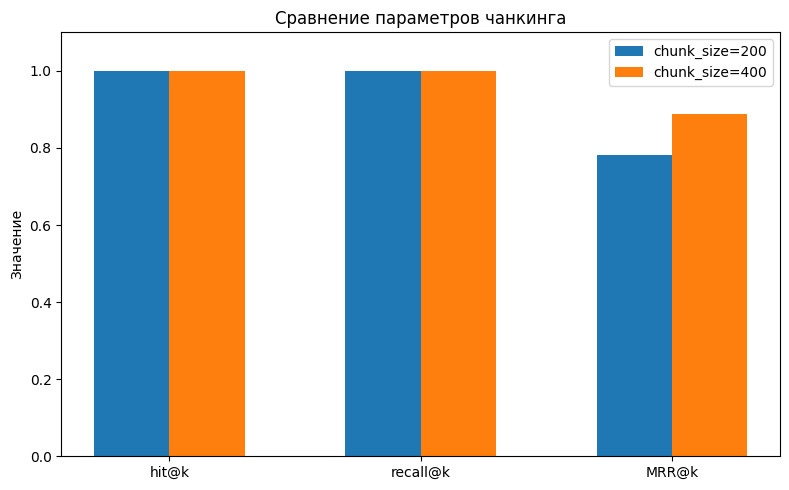

Сохранено: artifacts/retrieval_quality_plot.png


In [11]:
# Визуализация
metrics = ['hit@k', 'recall@k', 'MRR@k']
v1_vals = [hit_k, recall_k, mrr_k]
v2_vals = [hit_v2, recall_v2, mrr_v2]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, v1_vals, width, label='chunk_size=200')
ax.bar(x + width/2, v2_vals, width, label='chunk_size=400')
ax.set_ylabel('Значение')
ax.set_title('Сравнение параметров чанкинга')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('artifacts/retrieval_quality_plot.png', dpi=150)
plt.show()
print('Сохранено: artifacts/retrieval_quality_plot.png')

## 7. Обновление базы знаний и переиндексация

Добавим 3 новых документа и покажем, как меняется retrieval.

In [12]:
new_documents = [
    {
        "id": "doc_21",
        "title": "Многопоточность и multiprocessing",
        "text": "Модуль threading реализует многопоточность в Python. GIL (Global Interpreter Lock) ограничивает параллельное выполнение потоков для CPU-bound задач. Для CPU-bound задач рекомендуется multiprocessing, который создаёт отдельные процессы. concurrent.futures предоставляет высокоуровневый интерфейс: ThreadPoolExecutor для I/O-bound и ProcessPoolExecutor для CPU-bound задач. Синхронизация потоков: Lock, RLock, Semaphore, Event, Condition. Queue из модуля queue обеспечивает потокобезопасную передачу данных."
    },
    {
        "id": "doc_22",
        "title": "NumPy — основы",
        "text": "NumPy — библиотека для работы с многомерными массивами и математическими операциями. Основной объект — ndarray. Создание массивов: np.array(), np.zeros(), np.ones(), np.arange(), np.linspace(). Операции выполняются поэлементно (broadcasting). Индексация: обычная, булева, fancy indexing. Методы: reshape(), transpose(), flatten(). Агрегации: sum(), mean(), std(), min(), max(). Линейная алгебра: np.dot(), np.linalg.inv(), np.linalg.eig(). NumPy массивы значительно быстрее Python-списков для числовых операций."
    },
    {
        "id": "doc_23",
        "title": "Pandas — основы",
        "text": "Pandas — библиотека для анализа и обработки табличных данных. Основные структуры: Series (одномерная) и DataFrame (двумерная). Чтение данных: pd.read_csv(), pd.read_excel(), pd.read_json(). Выбор данных: df['col'], df.loc[], df.iloc[]. Фильтрация: df[df['col'] > 5]. Группировка: df.groupby('col').agg(). Объединение: pd.merge(), pd.concat(). Обработка пропусков: df.fillna(), df.dropna(). apply() — применение функции к столбцу. pivot_table() — сводные таблицы."
    }
]

# Запросы, на которые до обновления базы не было хороших ответов
update_queries = [
    "Как использовать threading и многопоточность?",
    "Что такое GIL в Python?",
    "Как создать массив ndarray в NumPy?",
    "Как прочитать CSV через read_csv в Pandas?",
    "Что делает groupby в Pandas?"
]

# Retrieval ДО обновления
print('=== До обновления ===')
before_results = []
for q in update_queries:
    results = search(q, index, embedder, chunks, top_k=3)
    retrieved = [r['chunk']['doc_id'] for r in results]
    before_results.append(retrieved)
    print(f'  "{q}" -> {retrieved}')

=== До обновления ===
  "Как использовать threading и многопоточность?" -> ['doc_03', 'doc_03', 'doc_19']
  "Что такое GIL в Python?" -> ['doc_16', 'doc_07', 'doc_11']
  "Как создать массив ndarray в NumPy?" -> ['doc_03', 'doc_03', 'doc_16']
  "Как прочитать CSV через read_csv в Pandas?" -> ['doc_09', 'doc_03', 'doc_07']
  "Что делает groupby в Pandas?" -> ['doc_10', 'doc_10', 'doc_10']


In [13]:
# Обновляем базу знаний
documents_updated = documents + new_documents
print(f'Документов до обновления: {len(documents)}')
print(f'Документов после обновления: {len(documents_updated)}')

# Переиндексация
chunks_updated = build_chunks(documents_updated, CHUNK_SIZE, OVERLAP)
print(f'Чанков после обновления: {len(chunks_updated)}')

chunk_texts_updated = [c['text'] for c in chunks_updated]
embedder_updated = TfidfEmbedder(dim=EMBED_DIM)
embeddings_updated = embedder_updated.fit_encode(chunk_texts_updated)
faiss.normalize_L2(embeddings_updated)

dim_updated = embeddings_updated.shape[1]
index_updated = faiss.IndexFlatIP(dim_updated)
index_updated.add(embeddings_updated)
print(f'Индекс FAISS обновлён: {index_updated.ntotal} векторов, размерность {dim_updated}')

Документов до обновления: 20
Документов после обновления: 23
Чанков после обновления: 95
Индекс FAISS обновлён: 95 векторов, размерность 64


In [14]:
# Retrieval ПОСЛЕ обновления
print('=== После обновления ===')
after_results = []
for q in update_queries:
    results = search(q, index_updated, embedder_updated, chunks_updated, top_k=3)
    retrieved = [r['chunk']['doc_id'] for r in results]
    after_results.append(retrieved)
    print(f'  "{q}" -> {retrieved}')

# Сравнение до/после
comparison_data = []
for q, before, after in zip(update_queries, before_results, after_results):
    comparison_data.append({
        'query': q,
        'before_retrieved_sources': '; '.join(before),
        'after_retrieved_sources': '; '.join(after),
        'changed': 'yes' if before != after else 'no'
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('artifacts/retrieval_before_after_update.csv', index=False)
print('\nСохранено: artifacts/retrieval_before_after_update.csv')
comparison_df

=== После обновления ===
  "Как использовать threading и многопоточность?" -> ['doc_03', 'doc_03', 'doc_21']
  "Что такое GIL в Python?" -> ['doc_21', 'doc_16', 'doc_22']
  "Как создать массив ndarray в NumPy?" -> ['doc_22', 'doc_03', 'doc_03']
  "Как прочитать CSV через read_csv в Pandas?" -> ['doc_23', 'doc_09', 'doc_03']
  "Что делает groupby в Pandas?" -> ['doc_23', 'doc_10', 'doc_10']

Сохранено: artifacts/retrieval_before_after_update.csv


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как использовать threading и многопоточность?,doc_03; doc_03; doc_19,doc_03; doc_03; doc_21,yes
1,Что такое GIL в Python?,doc_16; doc_07; doc_11,doc_21; doc_16; doc_22,yes
2,Как создать массив ndarray в NumPy?,doc_03; doc_03; doc_16,doc_22; doc_03; doc_03,yes
3,Как прочитать CSV через read_csv в Pandas?,doc_09; doc_03; doc_07,doc_23; doc_09; doc_03,yes
4,Что делает groupby в Pandas?,doc_10; doc_10; doc_10,doc_23; doc_10; doc_10,yes


## 8. Mini-RAG

Собираем простой mini-RAG: извлечение контекста -> формирование ответа по шаблону.

Для генерации ответа используем шаблонный подход: извлекаем релевантные фрагменты и формируем ответ на их основе.

In [15]:
def mini_rag(query, index, embedder, chunks, top_k=3):
    """Mini-RAG: retrieval + генерация ответа по шаблону."""
    results = search(query, index, embedder, chunks, top_k)
    
    if not results:
        return {
            'question': query,
            'answer': 'Не удалось найти релевантную информацию.',
            'sources': [],
            'context': '',
            'top_score': 0.0
        }
    
    # Собираем контекст из top-k чанков
    context_parts = []
    sources = []
    for r in results:
        context_parts.append(r['chunk']['text'])
        source = f"{r['chunk']['doc_id']} ({r['chunk']['title']}, чанк {r['chunk']['chunk_idx']})"
        if source not in sources:
            sources.append(source)
    
    context = '\n---\n'.join(context_parts)
    best_fragment = results[0]['chunk']['text']
    score = results[0]['score']
    
    # Формируем ответ на основе найденного контекста
    if score > 0.5:
        answer = f"На основе базы знаний: {best_fragment}"
    elif score > 0.2:
        answer = f"Частично релевантная информация: {best_fragment}"
    else:
        answer = f"Найдена информация с низкой релевантностью (score={score:.2f}): {best_fragment}"
    
    return {
        'question': query,
        'answer': answer,
        'sources': sources,
        'context': context,
        'top_score': score
    }


# Используем обновлённую базу знаний
rag_questions = [
    "Как создать список в Python?",
    "Что такое декоратор и для чего он нужен?",
    "Как обрабатывать исключения в Python?",
    "Чем отличается threading от multiprocessing?",
    "Как работать с DataFrame в Pandas?",
    "Что такое генератор и yield в Python?",
    "Как использовать регулярные выражения re?",
    "Как установить пакет через pip?"
]

rag_results = []
for q in rag_questions:
    result = mini_rag(q, index_updated, embedder_updated, chunks_updated)
    rag_results.append(result)
    print(f'Q: {result["question"]}')
    print(f'A: {result["answer"][:200]}...')
    print(f'Источники: {result["sources"]}')
    print(f'Score: {result["top_score"]:.3f}')
    print()

Q: Как создать список в Python?
A: На основе базы знаний: жества, который можно использовать как ключ словаря....
Источники: ['doc_03 (Множества в Python, чанк 3)', 'doc_03 (Множества в Python, чанк 2)', 'doc_01 (Списки в Python, чанк 0)']
Score: 0.596

Q: Что такое декоратор и для чего он нужен?
A: На основе базы знаний: нный класс. Встроенные декораторы: @property, @classmethod, @staticmethod. functools.lru_cache — встроенный декоратор для кэширования результатов функции....
Источники: ['doc_12 (Декораторы в Python, чанк 3)', 'doc_12 (Декораторы в Python, чанк 2)', 'doc_16 (Асинхронное программирование в Python, чанк 3)']
Score: 0.813

Q: Как обрабатывать исключения в Python?
A: На основе базы знаний: исключения, наследуясь от Exception. Оператор raise выбрасывает исключение. Контекстные менеджеры (with) обеспечивают корректное освобождение ресурсов. Основные встроенные исклю...
Источники: ['doc_08 (Обработка исключений в Python, чанк 2)', 'doc_08 (Обработка исключений в Python, чанк

In [16]:
# Сохраняем примеры RAG
rag_df = pd.DataFrame([{
    'question': r['question'],
    'answer': r['answer'],
    'retrieved_sources': '; '.join(r['sources'])
} for r in rag_results])

rag_df.to_csv('artifacts/rag_examples.csv', index=False)
print('Сохранено: artifacts/rag_examples.csv')
rag_df

Сохранено: artifacts/rag_examples.csv


,question,answer,retrieved_sources
0,Как создать список в Python?,"На основе базы знаний: жества, который можно и...","doc_03 (Множества в Python, чанк 3); doc_03 (М..."
1,Что такое декоратор и для чего он нужен?,На основе базы знаний: нный класс. Встроенные ...,"doc_12 (Декораторы в Python, чанк 3); doc_12 (..."
2,Как обрабатывать исключения в Python?,"На основе базы знаний: исключения, наследуясь ...","doc_08 (Обработка исключений в Python, чанк 2)..."
3,Чем отличается threading от multiprocessing?,"На основе базы знаний: ше памяти, чем списки, ...","doc_04 (Кортежи в Python, чанк 3); doc_21 (Мно..."
4,Как работать с DataFrame в Pandas?,На основе базы знаний: Pandas — библиотека для...,"doc_23 (Pandas — основы, чанк 0); doc_03 (Множ..."
5,Что такое генератор и yield в Python?,"На основе базы знаний: Итератор — объект, реал...","doc_13 (Генераторы и итераторы в Python, чанк ..."
6,Как использовать регулярные выражения re?,На основе базы знаний: ачале строки. re.findal...,"doc_14 (Модуль re — регулярные выражения, чанк..."
7,Как установить пакет через pip?,На основе базы знаний: ли myenv\Scripts\activa...,"doc_15 (Виртуальные окружения и pip, чанк 1); ..."


## 9. Анализ ошибок mini-RAG

In [17]:
# Примеры пограничных/неудачных запросов
edge_queries = [
    "Как подключиться к базе данных PostgreSQL?",  # Нет в базе знаний
    "Сравни Python и JavaScript",                  # Слишком общий запрос
    "Какой метод быстрее: sort или sorted?",       # Специфический вопрос
    "Как развернуть приложение на сервере?",       # Нет в базе знаний
]

print('=== Анализ пограничных случаев ===')
for q in edge_queries:
    result = mini_rag(q, index_updated, embedder_updated, chunks_updated)
    print(f'\nQ: {result["question"]}')
    print(f'Score лучшего результата: {result["top_score"]:.3f}')
    print(f'Источники: {result["sources"][:2]}')
    
    score = result['top_score']
    if score < 0.15:
        print('-> Проблема: низкая релевантность, тема отсутствует в базе знаний.')
    elif score < 0.3:
        print('-> Проблема: частичное совпадение, ответ может быть неполным.')
    else:
        print('-> Retrieval нашел частично подходящий фрагмент, но вопрос не полностью покрыт базой.')

=== Анализ пограничных случаев ===

Q: Как подключиться к базе данных PostgreSQL?
Score лучшего результата: 0.566
Источники: ['doc_03 (Множества в Python, чанк 3)', 'doc_03 (Множества в Python, чанк 2)']
-> Retrieval нашел частично подходящий фрагмент, но вопрос не полностью покрыт базой.

Q: Сравни Python и JavaScript
Score лучшего результата: 0.499
Источники: ['doc_22 (NumPy — основы, чанк 3)', 'doc_07 (Классы и ООП в Python, чанк 0)']
-> Retrieval нашел частично подходящий фрагмент, но вопрос не полностью покрыт базой.

Q: Какой метод быстрее: sort или sorted?
Score лучшего результата: 0.713
Источники: ['doc_01 (Списки в Python, чанк 2)', 'doc_01 (Списки в Python, чанк 1)']
-> Retrieval нашел частично подходящий фрагмент, но вопрос не полностью покрыт базой.

Q: Как развернуть приложение на сервере?
Score лучшего результата: 0.664
Источники: ['doc_16 (Асинхронное программирование в Python, чанк 3)', 'doc_03 (Множества в Python, чанк 3)']
-> Retrieval нашел частично подходящий фрагме

### Комментарий по ошибкам

1. **"Как подключиться к PostgreSQL?"** — тема баз данных отсутствует в базе знаний. Retrieval вернул наиболее похожие фрагменты (работа с файлами / json / csv), но они нерелевантны. Это ограничение неполноты базы.

2. **"Сравни Python и JavaScript"** — запрос слишком общий и выходит за рамки справочника. Retrieval вернул фрагменты о Python, но сравнения с JavaScript нет.

3. **"sort или sorted"** — информация есть в doc_01, но вопрос о производительности не раскрыт в базе. Retrieval находит нужный документ, но контекст не даёт прямого ответа на вопрос о скорости.

4. **"Развернуть приложение на сервере"** — тема деплоя отсутствует. Retrieval может вернуть фрагменты о виртуальных окружениях, но это не отвечает на вопрос.

In [18]:
print('\n=== Итого ===')
print(f'Документов в базе (после обновления): {len(documents_updated)}')
print(f'Чанков (после обновления): {len(chunks_updated)}')
print(f'Способ векторизации: TF-IDF + TruncatedSVD (dim={EMBED_DIM})')
print(f'Индекс: FAISS IndexFlatIP (cosine similarity)')
print(f'hit@{TOP_K}: {hit_k:.3f}')
print(f'recall@{TOP_K}: {recall_k:.3f}')
print(f'MRR@{TOP_K}: {mrr_k:.3f}')
print(f'Артефакты сохранены в artifacts/')


=== Итого ===
Документов в базе (после обновления): 23
Чанков (после обновления): 95
Способ векторизации: TF-IDF + TruncatedSVD (dim=64)
Индекс: FAISS IndexFlatIP (cosine similarity)
hit@5: 1.000
recall@5: 1.000
MRR@5: 0.781
Артефакты сохранены в artifacts/
